In [1]:
# STEP 1: Install required library
!pip install imbalanced-learn -q

In [2]:
# STEP 2: Import libraries
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from skimage.feature import local_binary_pattern

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE

In [3]:
# STEP 3: Extract Dataset.zip cleanly

zip_path = "/content/Brain_tumour.zip"
extract_path = "/content/extracted_dataset"

if os.path.exists(extract_path):
    import shutil
    shutil.rmtree(extract_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [4]:
import os
import shutil

source_dataset_path = "/content/extracted_dataset"
combined_dataset_path = "/content/Brain_Dataset"

# remove old folder
if os.path.exists(combined_dataset_path):
    shutil.rmtree(combined_dataset_path)

# create folders
os.makedirs(os.path.join(combined_dataset_path, "yes"), exist_ok=True)
os.makedirs(os.path.join(combined_dataset_path, "no"), exist_ok=True)

# copy Apple images
apple_source = os.path.join(source_dataset_path, "yes")
apple_dest = os.path.join(combined_dataset_path, "yes")

for file_name in os.listdir(apple_source):

    source_file = os.path.join(apple_source, file_name)

    if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):

        shutil.copy2(source_file, apple_dest)

# copy Tomato images
tomato_source = os.path.join(source_dataset_path, "no")
tomato_dest = os.path.join(combined_dataset_path, "no")

for file_name in os.listdir(tomato_source):

    source_file = os.path.join(tomato_source, file_name)

    if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):

        shutil.copy2(source_file, tomato_dest)

print("Dataset organized successfully!")

print("yes images:", len(os.listdir(apple_dest)))
print("no images:", len(os.listdir(tomato_dest)))

Dataset organized successfully!
yes images: 155
no images: 98


In [8]:
# STEP: Set dataset directory

dataset_path = "/content/Brain_Dataset"

yes_path = os.path.join(dataset_path, "yes")
no_path = os.path.join(dataset_path, "no")

print("yes images:", len(os.listdir(yes_path)))
print("No images:", len(os.listdir(no_path)))

yes images: 155
No images: 98


In [9]:
image_paths = []
labels = []

class_map = {
    "yes": 0,
    "no": 1
}

for class_name, label in class_map.items():
    folder_path = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(folder_path):

        if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            full_path = os.path.join(folder_path, file_name)

            image_paths.append(full_path)
            labels.append(label)

print("Total images found:", len(image_paths))
print("Total labels:", len(labels))
print("First image path:", image_paths[0])

Total images found: 253
Total labels: 253
First image path: /content/Brain_Dataset/yes/Y109.JPG


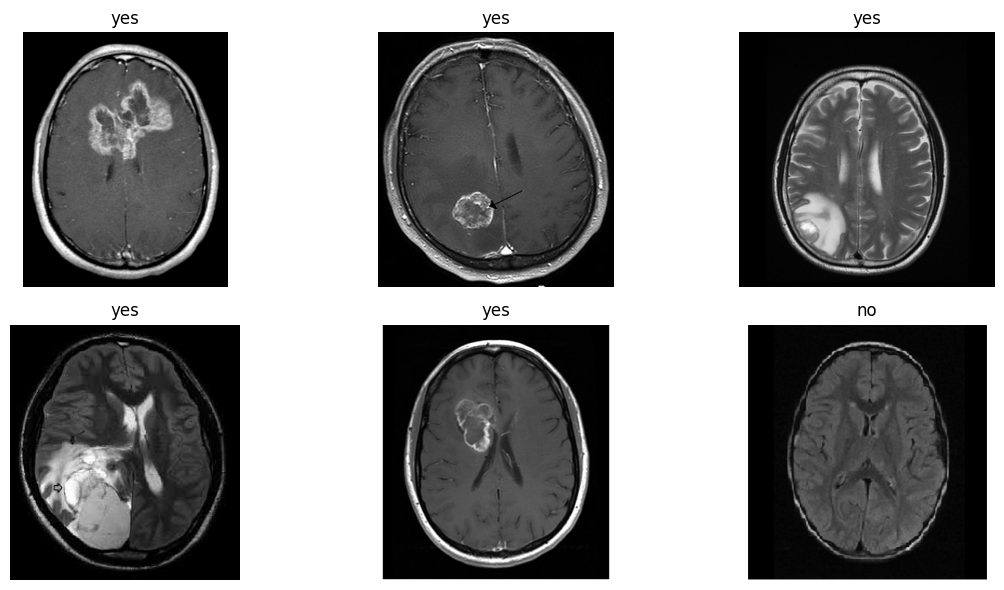

In [10]:
import cv2
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(12, 6))

for i in range(6):
    idx = random.randint(0, len(image_paths) - 1)

    img_path = image_paths[idx]
    img = cv2.imread(img_path)

    if img is None:
        print("Could not read:", img_path)
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    class_name = "yes" if labels[idx] == 0 else "no"

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
def show_sample_images(dataset_path, samples=4):

    classes = ["yes", "no"]

    plt.figure(figsize=(4 * samples, 8))

    plot_index = 1

    for class_name in classes:

        folder_path = os.path.join(dataset_path, class_name)

        image_files = os.listdir(folder_path)[:samples]

        for file_name in image_files:

            img_path = os.path.join(folder_path, file_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(2, samples, plot_index)
            plt.imshow(img_rgb)

            plt.title(class_name)
            plt.axis("off")

            plot_index += 1

    plt.tight_layout()
    plt.show()

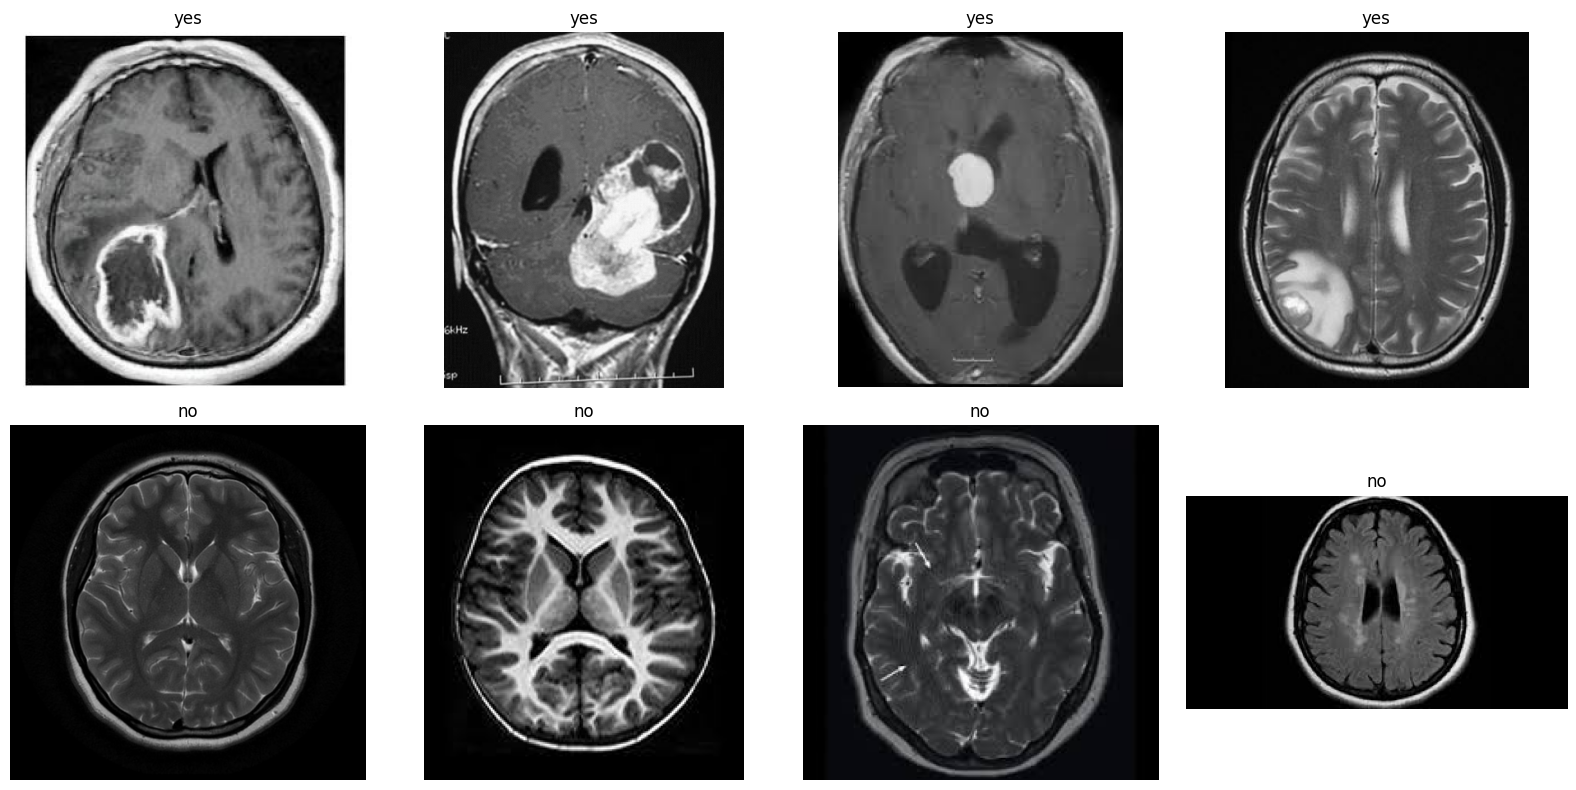

In [12]:
show_sample_images("/content/Brain_Dataset", samples=4)

In [13]:
def preprocess_image(img):

    # 1. Resize image
    resized = cv2.resize(img, (128, 128))

    # 2. Noise removal
    denoised = cv2.medianBlur(resized, 5)

    # 3. Convert to grayscale
    gray = cv2.cvtColor(denoised, cv2.COLOR_BGR2GRAY)

    # 4. Histogram Equalization
    equalized = cv2.equalizeHist(gray)

    # 5. Convert to HSV
    hsv = cv2.cvtColor(denoised, cv2.COLOR_BGR2HSV)

    # 6. Edge Detection
    edges = cv2.Canny(equalized, 100, 200)

    return resized, denoised, gray, equalized, hsv, edges

In [14]:
def show_preprocessing_steps(img_path):

    img = cv2.imread(img_path)

    if img is None:
        print("Image could not be loaded")
        return

    # Original image for display
    original_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply preprocessing
    resized, denoised, gray, equalized, hsv, edges = preprocess_image(img)

    # Convert BGR images to RGB for matplotlib
    resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    denoised_rgb = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(18, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(original_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(resized_rgb)
    plt.title("Resized")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(denoised_rgb)
    plt.title("Denoised")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(equalized, cmap="gray")
    plt.title("Histogram Equalized")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(edges, cmap="gray")
    plt.title("Edge Detection")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

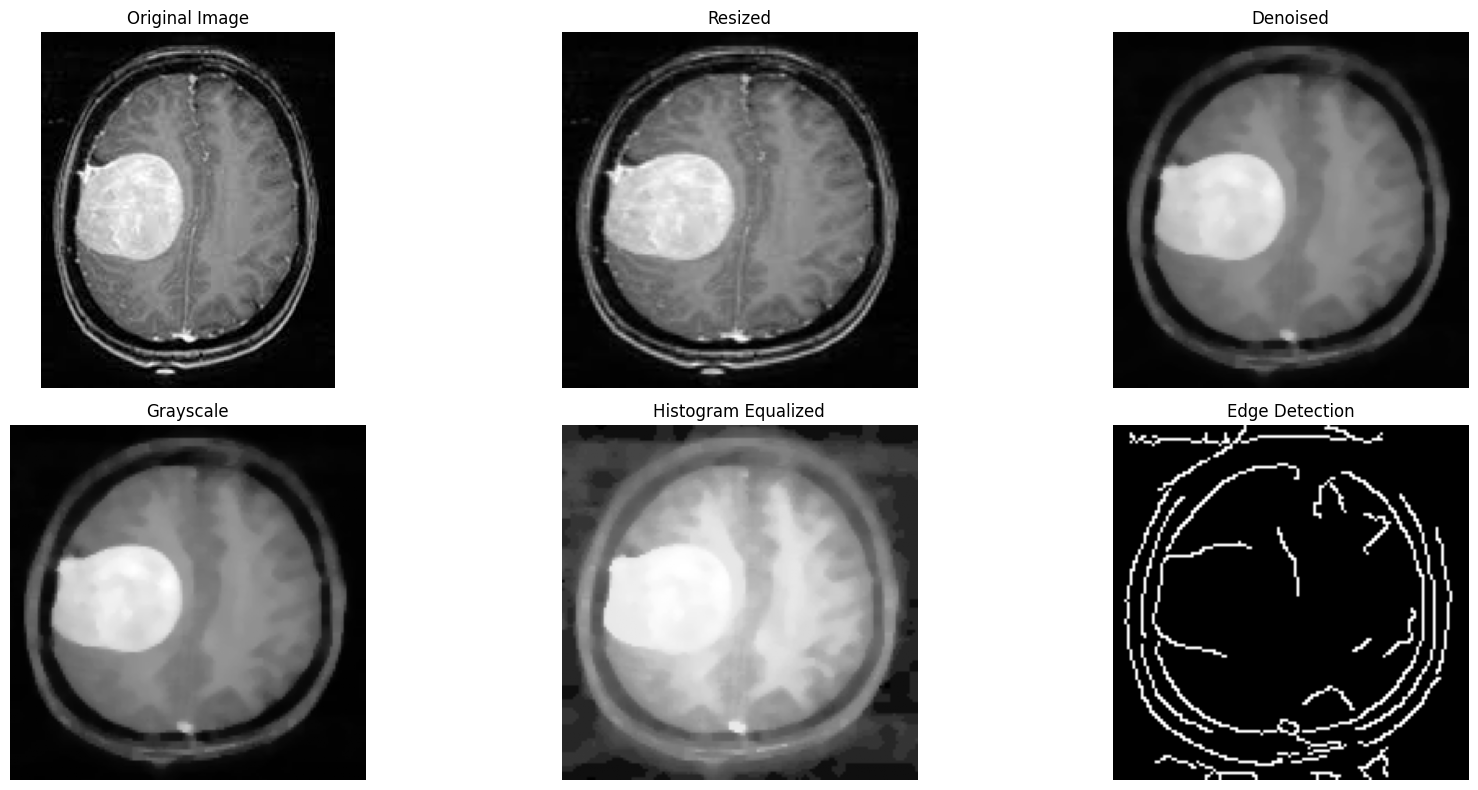

In [16]:
show_preprocessing_steps(
    "/content/extracted_dataset/yes/Y1.jpg"
)

In [17]:
def show_contours(img_path):

    img = cv2.imread(img_path)

    if img is None:
        print("Image not found")
        return

    resized = cv2.resize(img, (128, 128))

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    contours, hierarchy = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contour_image = resized.copy()

    cv2.drawContours(
        contour_image,
        contours,
        -1,
        (0, 255, 0),
        2
    )

    contour_rgb = cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(contour_rgb)

    plt.title(f"Contours Found: {len(contours)}")
    plt.axis("off")

    plt.show()

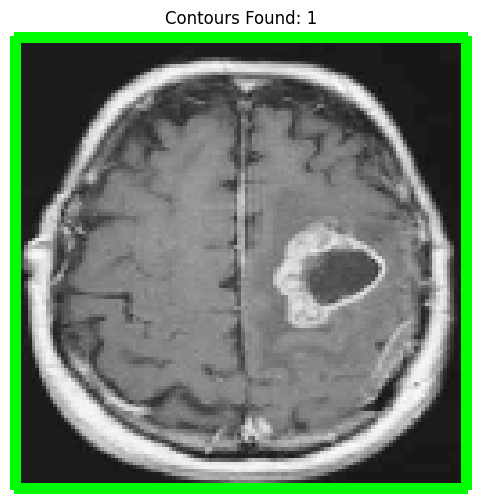

In [18]:
show_contours(
    "/content/extracted_dataset/yes/Y10.jpg"
)

In [19]:
from skimage.feature import local_binary_pattern

def extract_features(img):

    features = []

    # =========================
    # PREPROCESSING
    # =========================

    resized = cv2.resize(img, (128, 128))

    denoised = cv2.medianBlur(resized, 5)

    gray = cv2.cvtColor(denoised, cv2.COLOR_BGR2GRAY)

    equalized = cv2.equalizeHist(gray)

    hsv = cv2.cvtColor(denoised, cv2.COLOR_BGR2HSV)

    edges = cv2.Canny(equalized, 100, 200)

    # =========================
    # 1. COLOR FEATURES
    # HSV Histogram
    # =========================

    h_hist = cv2.calcHist([hsv], [0], None, [32], [0, 180])

    h_hist = h_hist.flatten()

    h_hist = h_hist / (h_hist.sum() + 1e-6)

    features.extend(h_hist)

    # =========================
    # 2. TEXTURE FEATURES
    # LBP
    # =========================

    lbp = local_binary_pattern(
        equalized,
        P=8,
        R=1,
        method="uniform"
    )

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=10,
        range=(0, 10)
    )

    lbp_hist = lbp_hist.astype("float32")

    lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-6)

    features.extend(lbp_hist)

    # =========================
    # 3. SHAPE FEATURES
    # =========================

    contours, hierarchy = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    area = sum(cv2.contourArea(c) for c in contours)

    perimeter = sum(cv2.arcLength(c, True) for c in contours)

    circularity = (4 * np.pi * area) / ((perimeter ** 2) + 1e-6)

    features.extend([
        area,
        perimeter,
        circularity
    ])

    return np.array(features, dtype=np.float32)

In [20]:
sample_img = cv2.imread(
    "/content/extracted_dataset/yes/Y1.jpg"
)
features = extract_features(sample_img)

print("Feature Vector Shape:", features.shape)

print("\nFirst 20 Features:\n")
print(features[:20])

Feature Vector Shape: (45,)

First 20 Features:

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [21]:
X = []
y = []

for img_path, label in zip(image_paths, labels):

    img = cv2.imread(img_path)

    # corrupted image handling
    if img is None:
        print("Skipping corrupted image:", img_path)
        continue

    try:
        feature_vector = extract_features(img)

        # remove invalid values
        if np.isfinite(feature_vector).all():

            X.append(feature_vector)
            y.append(label)

    except Exception as e:
        print("Error processing:", img_path)
        print(e)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Feature Matrix Shape:", X.shape)
print("Label Vector Shape:", y.shape)

Feature Matrix Shape: (253, 45)
Label Vector Shape: (253,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Labels:")
print(np.bincount(y_train))

print("\nTesting Labels:")
print(np.bincount(y_test))

Training Data Shape: (202, 45)
Testing Data Shape: (51, 45)

Training Labels:
[124  78]

Testing Labels:
[31 20]


In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(np.bincount(y_train))

print("\nAfter SMOTE:")
print(np.bincount(y_train_smote))

print("\nBalanced Training Shape:")
print(X_train_smote.shape)

Before SMOTE:
[124  78]

After SMOTE:
[124 124]

Balanced Training Shape:
(248, 45)


In [24]:
models = {

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Extra Trees": ExtraTreesClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Naive Bayes": GaussianNB()
}

results = []

for model_name, model in models.items():

    pipeline = Pipeline([

        ("scaler", StandardScaler()),

        ("classifier", model)
    ])

    pipeline.fit(X_train_smote, y_train_smote)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([model_name, accuracy])

    print(f"{model_name} Accuracy: {accuracy:.4f}")

KNN Accuracy: 0.7255
SVM Accuracy: 0.6275
Random Forest Accuracy: 0.7059
Logistic Regression Accuracy: 0.7255
Decision Tree Accuracy: 0.6667
Extra Trees Accuracy: 0.8235
Gradient Boosting Accuracy: 0.7059
Naive Bayes Accuracy: 0.4118


In [25]:
best_model = ExtraTreesClassifier(random_state=42)

best_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("classifier", best_model)
])

best_pipeline.fit(X_train_smote, y_train_smote)

y_pred = best_pipeline.predict(X_test)

In [26]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nPrecision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Apple", "Tomato"]
    )
)

Accuracy : 0.8235294117647058

Precision : 0.8235294117647058
Recall : 0.7
F1 Score : 0.7567567567567568

Classification Report:

              precision    recall  f1-score   support

       Apple       0.82      0.90      0.86        31
      Tomato       0.82      0.70      0.76        20

    accuracy                           0.82        51
   macro avg       0.82      0.80      0.81        51
weighted avg       0.82      0.82      0.82        51



[[28  3]
 [ 6 14]]


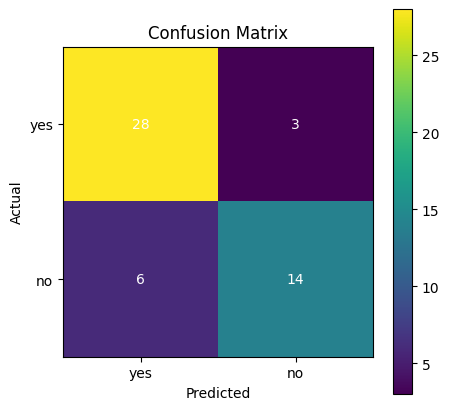

In [27]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1], ["yes", "no"])
plt.yticks([0,1], ["yes", "no"])

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white"
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

# probability scores
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score :", auc_score)

AUC Score : 0.8516129032258065


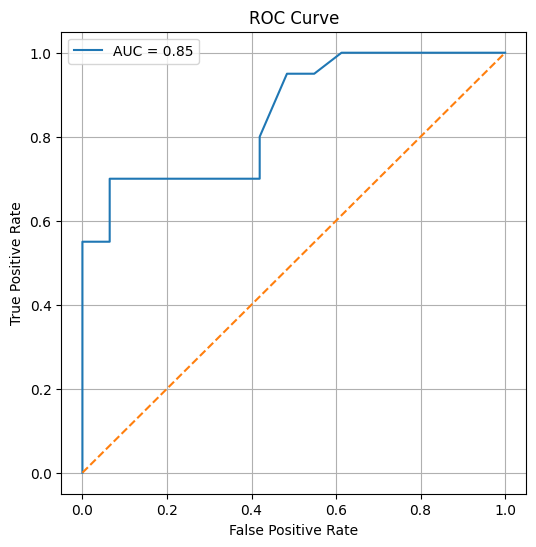

In [29]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [30]:
train_sizes, train_scores, validation_scores = learning_curve(

    estimator=best_pipeline,

    X=X_train_smote,

    y=y_train_smote,

    train_sizes=np.linspace(0.1, 1.0, 6),

    cv=5,

    scoring="accuracy"
)

In [31]:
train_mean = np.mean(train_scores, axis=1)

validation_mean = np.mean(validation_scores, axis=1)

print("Training Accuracy:\n")
print(train_mean)

print("\nValidation Accuracy:\n")
print(validation_mean)

Training Accuracy:

[1. 1. 1. 1. 1. 1.]

Validation Accuracy:

[0.5362449  0.59689796 0.68987755 0.72636735 0.77061224 0.82269388]


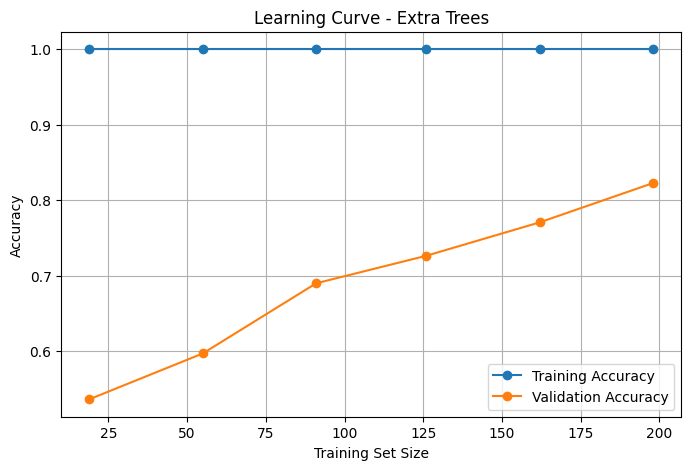

In [33]:

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker='o',
    label="Validation Accuracy"
)

plt.xlabel("Training Set Size")

plt.ylabel("Accuracy")

plt.title("Learning Curve - Extra Trees")

plt.legend()

plt.grid(True)

plt.show()

Total Features: 45

Top 10 Important Features:

        Feature  Importance
36        LBP_4    0.106220
35        LBP_3    0.090935
40        LBP_8    0.080734
38        LBP_6    0.071541
37        LBP_5    0.070142
42         Area    0.065386
43    Perimeter    0.064794
33        LBP_1    0.062341
44  Circularity    0.060414
41        LBP_9    0.058966


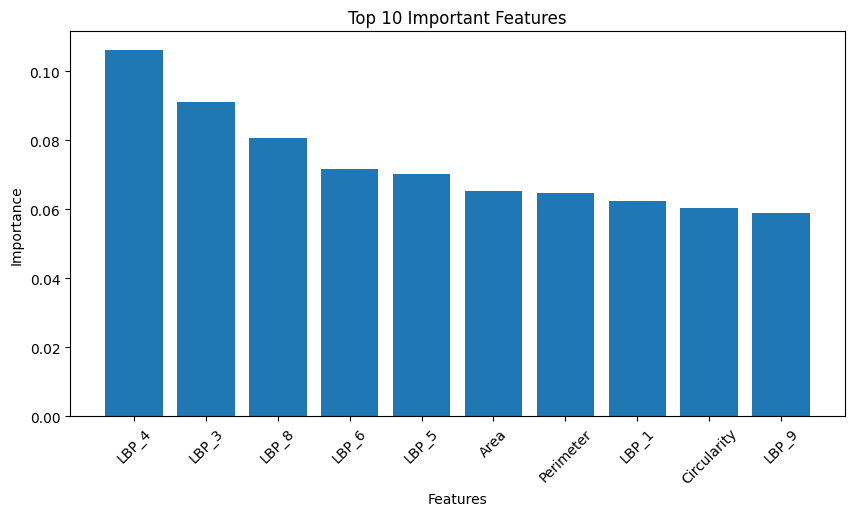

In [34]:
# =========================
# FEATURE IMPORTANCE
# =========================

feature_importance = best_pipeline.named_steps[
    "classifier"
].feature_importances_

print("Total Features:", len(feature_importance))


# =========================
# FEATURE NAMES
# =========================

feature_names = []

# HSV Histogram Features
for i in range(32):
    feature_names.append(f"HSV_Hist_{i}")

# LBP Texture Features
for i in range(10):
    feature_names.append(f"LBP_{i}")

# Shape Features
feature_names.extend([
    "Area",
    "Perimeter",
    "Circularity"
])


# =========================
# CREATE DATAFRAME
# =========================

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)


# =========================
# PRINT TOP FEATURES
# =========================

print("\nTop 10 Important Features:\n")

print(importance_df.head(10))


# =========================
# VISUALIZATION
# =========================

top_features = importance_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Top 10 Important Features")

plt.show()

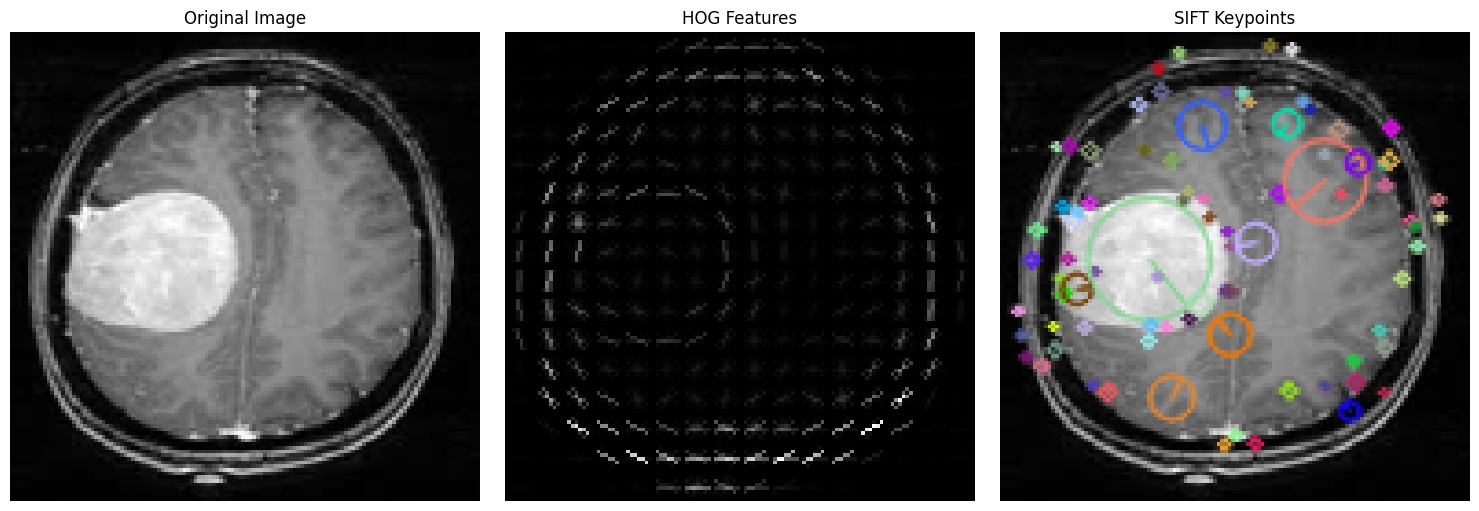

HOG Feature Vector Length: 8100
Number of SIFT Keypoints: 88


In [36]:
# =========================
# HOG + SIFT VISUALIZATION
# =========================

from skimage.feature import hog

img_path = "/content/extracted_dataset/yes/Y1.jpg"

img = cv2.imread(img_path)

# resize
img = cv2.resize(img, (128, 128))

# grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# =========================
# HOG FEATURE VISUALIZATION
# =========================

hog_features, hog_image = hog(

    gray,

    orientations=9,

    pixels_per_cell=(8, 8),

    cells_per_block=(2, 2),

    visualize=True
)


# =========================
# SIFT FEATURE VISUALIZATION
# =========================

sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(
    gray,
    None
)

sift_image = cv2.drawKeypoints(

    img,

    keypoints,

    None,

    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)


# =========================
# DISPLAY RESULTS
# =========================

plt.figure(figsize=(15,5))


# Original Image
plt.subplot(1,3,1)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.title("Original Image")

plt.axis("off")


# HOG Visualization
plt.subplot(1,3,2)

plt.imshow(hog_image, cmap="gray")

plt.title("HOG Features")

plt.axis("off")


# SIFT Visualization
plt.subplot(1,3,3)

plt.imshow(cv2.cvtColor(sift_image, cv2.COLOR_BGR2RGB))

plt.title("SIFT Keypoints")

plt.axis("off")


plt.tight_layout()

plt.show()


# =========================
# PRINT FEATURE DETAILS
# =========================

print("HOG Feature Vector Length:", len(hog_features))

print("Number of SIFT Keypoints:", len(keypoints))